In [1]:
import gym
import matplotlib.pyplot as plt
import numpy as np


In [2]:
import json
import glob
import os
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from IPython import display

In [3]:
from learn_frame import LearningFrame
from models.rl.dqn import DQN, DDQN
from models.rl.sac import Discrete_SAC
from data.envdata import EnvData
from networks.FFN import LayerGenerator
def train(episodes = 500):
    for i in range(episodes):
        while(not lf.train()):
            pass
        if i%25 == 0:
            lf.plot_durations()
    lf.plot_durations(show_result= True)

def train_sac(episodes = 500):
    for i in range(episodes):
        while(not lf.train(duration=False)):
            pass
        lf.durations.append(lf.test())
        if i%25 == 0:
            lf.plot_durations()
    lf.plot_durations(show_result= True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = gym.make("CartPole-v1", render_mode="rgb_array")


In [4]:
q_arch_params = {
    "layers" : [4,128,128,2],
    "type" : nn.Linear,
    "decs" : [],
    "args" : [],
    "hidden_act" : nn.ReLU,
    "out_act" : nn.Identity,
    "weight_init" : "uniform"
}
qnet_params = {
    "arch_params" : [q_arch_params],
    "device": device,
    "optimizer": optim.AdamW,
    "lr": 2*1e-4,
    "weight_decay": 0
}

eps_params = {
    "eps": 0.9,
    "eps_end": 0.05,
    "eps_decay": 1000
}

ddqn_params = {
    "network_params": qnet_params,
    "device": device,
    "criterion": nn.MSELoss,
    "gamma": 0.99,
    "tau": 0.005,
    "eps_params" : None
}

p_arch_params = {
    "layers" : [4,128,128,2],
    "type" : nn.Linear,
    "decs" : [],
    "args" : [],
    "hidden_act" : nn.ReLU,
    "out_act" : nn.Softmax,
    "weight_init" : "uniform"
}
pnet_params = {
    "arch_params" : [p_arch_params],
    "device": device,
    "optimizer": optim.AdamW,
    "lr": 2*1e-4,
    "weight_decay": 0
}

sac_params = {
    "ddqn_params": ddqn_params,
    "pnet_params": pnet_params,
    "alpha_lr" : 2*1e-4,
    "criterion": nn.MSELoss,
    "target_entropy_coeff": 1.,
    "gamma": 0.99,
    "device" : device
}




In [5]:
model = Discrete_SAC(**sac_params)
data = EnvData(env, 20000, device= device)
lf = LearningFrame(model, data, batch_size = 128, start_size = 128)
durations = []

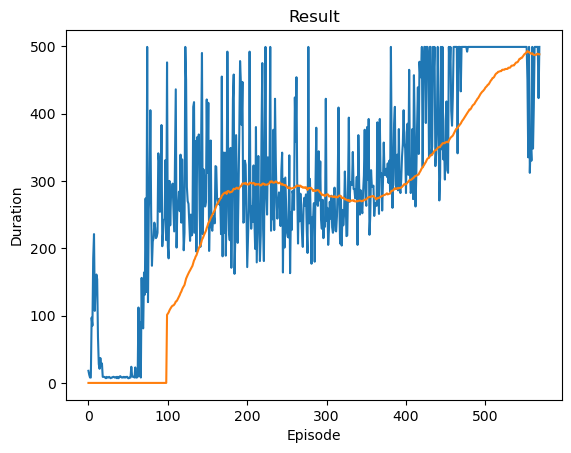

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
train_sac(episodes=500)

In [10]:
dqn_params = {
    "network_params": qnet_params,
    "device": device,
    "criterion": nn.MSELoss,
    "gamma": 0.99,
    "tau": 0.005,
    "eps_params" : eps_params,
    "variant" : "DQN"
}
model = DQN(**dqn_params)
data = EnvData(env, 10000, device= device)
lf = LearningFrame(model, data, batch_size = 128, start_size = 128)
durations = []

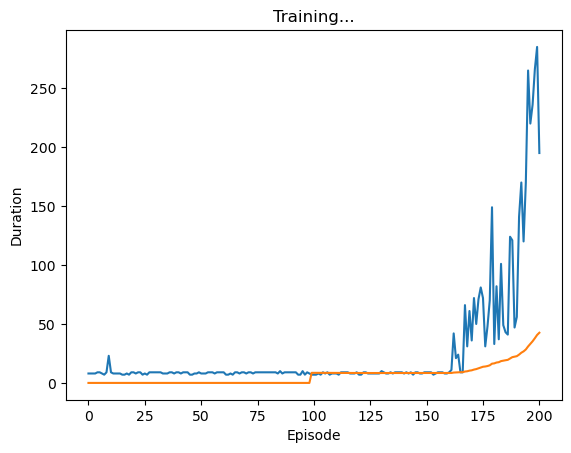

<Figure size 640x480 with 0 Axes>

In [ ]:
train_sac(episodes=500)

In [4]:
network_params = {
    "layers": [4,128,128,2],
    "dataset": None,
    "task": "reg",
    "hidden_act": nn.ReLU,
    "out_act": nn.Identity,
    "criterion": nn.MSELoss,
    "device": device,
    "optimizer": optim.AdamW,
    "lr": 1e-4,
    "batch_size": None,
    "dropout": None,
    "weight_decay": 0,
    "model_final": False,
    "weight_init": "uniform"
}

eps_params = {
    "eps": 0.9,
    "eps_end": 0.05,
    "eps_decay": 1000
}

ddqn_params = {
    "network_params": network_params,
    "device": device,
    "criterion": nn.MSELoss,
    "gamma": 0.99,
    "tau": 0.005,
    "eps_params" : None
}

In [5]:
arch_params = {
    "layers" : [4,128,128,2],
    "type" : nn.Linear,
    "decs" : [],
    "args" : [],
    "hidden_act" : nn.ReLU,
    "out_act" : nn.Softmax,
    "weight_init" : "uniform"
}
pnet_params = {
    "arch_params" : arch_params
    "device": device,
    "optimizer": optim.AdamW,
    "lr": 1e-4,
    "weight_decay": 0
}

sac_params = {
    "ddqn_params": ddqn_params,
    "pnet_params": pnet_params,
    "alpha_lr" : 1e-4,
    "criterion": nn.MSELoss,
    "target_entropy_coeff": 1.,
    "gamma": 0.99,
    "device" : device
}
model = Discrete_SAC(**sac_params)
data = EnvData(env, 10000, device= device)
lf = LearningFrame(model, data, batch_size = 128, start_size = 128)
durations = []


In [6]:
FFN_args = {
layers : [4,128,128,2],
type : nn.Linear,
hidden_act : nn.ReLU,
out_act : nn.ReLU,
weight_init : "uniform"
}

NameError: name 'layers' is not defined

In [11]:
train(episodes = 600)

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [9]:



model = DDQN(**ddqn_params)
data = EnvData(env, 10000, device= device)
lf = LearningFrame(model, data, batch_size = 128, start_size = 128)
durations = []

In [ ]:
train()